In [1]:
%matplotlib widget

In [14]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections, re
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib.collections import LineCollection

In [3]:
data = pd.read_csv("final_defesas_2006a2024.csv")
data_filiacao = pd.read_csv("csvs/filiacao.csv")
data_genero = pd.read_csv("csvs/genero2.csv")

## Criação de nós

In [4]:
padrao_avaliadores = 'avaliador\d$'
avaliadores = [col for col in data.columns if re.search(padrao_avaliadores, col)]
avaliadores.append("orientador")

In [5]:
uni_key = {uni:key for key, uni in enumerate(data_filiacao["filiacao padronizada"].unique())}

In [6]:
css4_colors = list(mcolors.CSS4_COLORS.keys())

# You can use the first 130 of these colors
palette_130 = css4_colors[:data_filiacao["filiacao padronizada"].unique().shape[0]]

In [7]:
grafo_defesas = nx.MultiDiGraph()
# grafo_defesas = nx.DiGraph()
n_banca = 0
filiacao_alvo = "Universidade Estadual de Campinas"
cor_nodes = []
cor_nodes_bin = []
marker_node = []
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        filiacao = data_filiacao[data_filiacao["orcid"] == url]["filiacao padronizada"].values[0]\
                                                            if data_filiacao[data_filiacao["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        genero = data_genero[data_genero["orcid"] == url]["genero"].values[0]\
                                                            if data_genero[data_genero["orcid"] == url].shape[0] !=0 \
                                                            else "não anotado"
        filiacao_genero=f'{genero}_{"interno" if filiacao==filiacao_alvo else "externo"}'
        grafo_defesas.add_node(
                            node_for_adding=url.split("/")[-1],
                            nome=data.at[index, f"{col}_nome"],
                            filiacao=filiacao,
                            genero=genero,
                            filiacao_genero=filiacao_genero,
                            bipartite=1 if genero == "Feminino" else 0,
                            marker="F" if genero == "Feminino" else "M",
                            cor_bin="red" if filiacao == filiacao_alvo else "blue",
                            cor=palette_130[uni_key[filiacao]]
                            )
    n_banca -=- 1

In [19]:
grafo_defesas.nodes["0000-0002-8803-0401"]

{'nome': 'Rodolfo Azevedo',
 'filiacao': 'Universidade Estadual de Campinas',
 'genero': 'Masculino',
 'filiacao_genero': 'Universidade Estadual de Campinas_Masculino',
 'bipartite': 0,
 'marker': 'M',
 'cor_bin': 'red',
 'cor': 'aliceblue'}

## Criação de arestas (arestas representam colaborações em defesas de mestrado, mestrado profissional ou doutorado)

In [8]:
size_nodes = []

for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        # if grafo_defesas.has_edge(orcid_orient, orcid_aval):
        #     grafo_defesas[orcid_orient][orcid_aval][0]["weight"] -=- 1
        #     continue
        grafo_defesas.add_edge(orcid_orient, orcid_aval, ano=row[1]["ano"], tipo=row[1]["tipo"])
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

In [32]:
filiacao_alvo = "Universidade Estadual de Campinas"
dict_ano = nx.get_edge_attributes(grafo_defesas, name="ano")
df_dict = collections.defaultdict(list)
for person1, person2, infos in grafo_defesas.edges(data=True):
    node1 = grafo_defesas.nodes[person1]
    node2 = grafo_defesas.nodes[person2]
    df_dict["orient_filiacao_bin"].append("Unicamp" if node1['filiacao'] == filiacao_alvo else "Externa/o")
    df_dict["aval_filiacao_bin"].append("Unicamp" if node2['filiacao'] == filiacao_alvo else "Externa/o")
    df_dict["orient_genero"].append(node1["genero"])
    df_dict["aval_genero"].append(node2["genero"])
    df_dict["ano_defesa"].append(infos["ano"])
    df_dict["tipo_defesa"].append(infos["tipo"])
    # break
df = pd.DataFrame(df_dict)

<Axes: xlabel='count', ylabel='aval_filiacao_bin'>

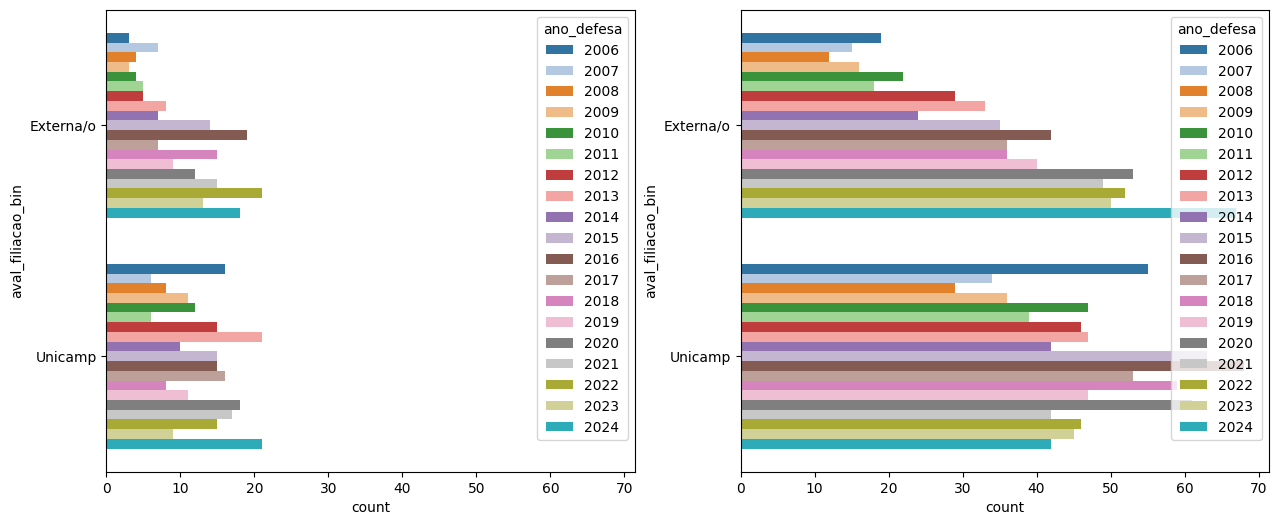

In [26]:
fig, ax = plt.subplots(ncols=2, figsize=(15,6), sharex=True)

sns.countplot(df[df["aval_genero"] == "Feminino"], y="aval_filiacao_bin", hue="ano_defesa", ax=ax[0], order=("Externa/o", "Unicamp"), palette="tab20")
sns.countplot(df[df["aval_genero"] == "Masculino"], y="aval_filiacao_bin", hue="ano_defesa", ax=ax[1], order=("Externa/o", "Unicamp"), palette="tab20")

<Axes: xlabel='count', ylabel='aval_filiacao_bin'>

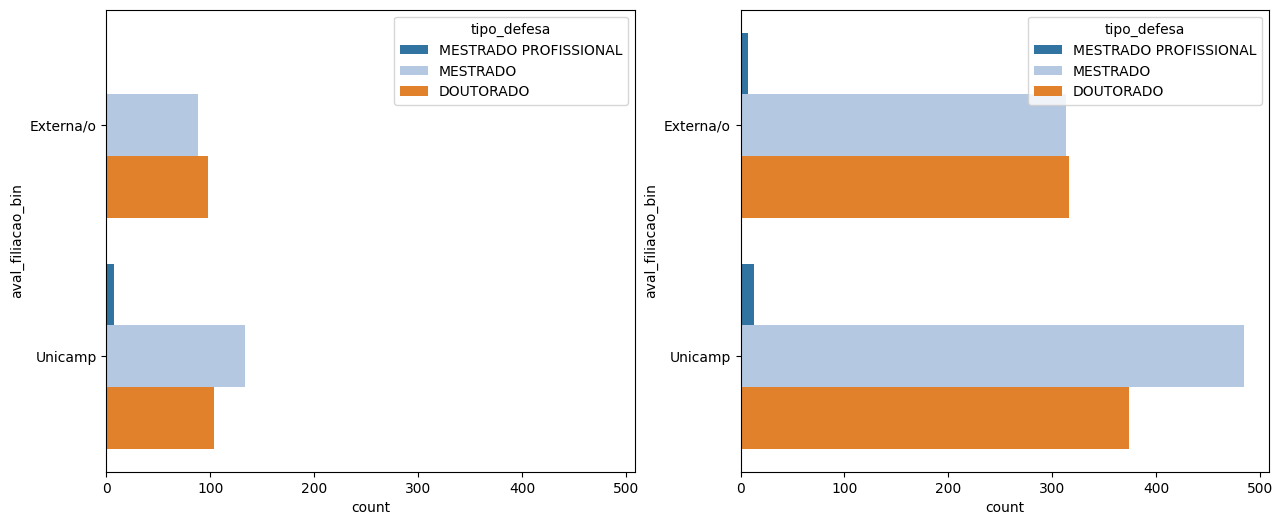

In [65]:
fig, ax = plt.subplots(ncols=2, figsize=(15,6), sharex=True)
hue_order = ["MESTRADO PROFISSIONAL", "MESTRADO", "DOUTORADO"]
sns.countplot(df[df["aval_genero"] == "Feminino"], y="aval_filiacao_bin", hue="tipo_defesa", ax=ax[0], order=("Externa/o", "Unicamp"),
              palette="tab20", hue_order=hue_order)
sns.countplot(df[df["aval_genero"] == "Masculino"], y="aval_filiacao_bin", hue="tipo_defesa", ax=ax[1], order=("Externa/o", "Unicamp"),
              palette="tab20", hue_order=hue_order)

<Axes: xlabel='count', ylabel='aval_filiacao_bin'>

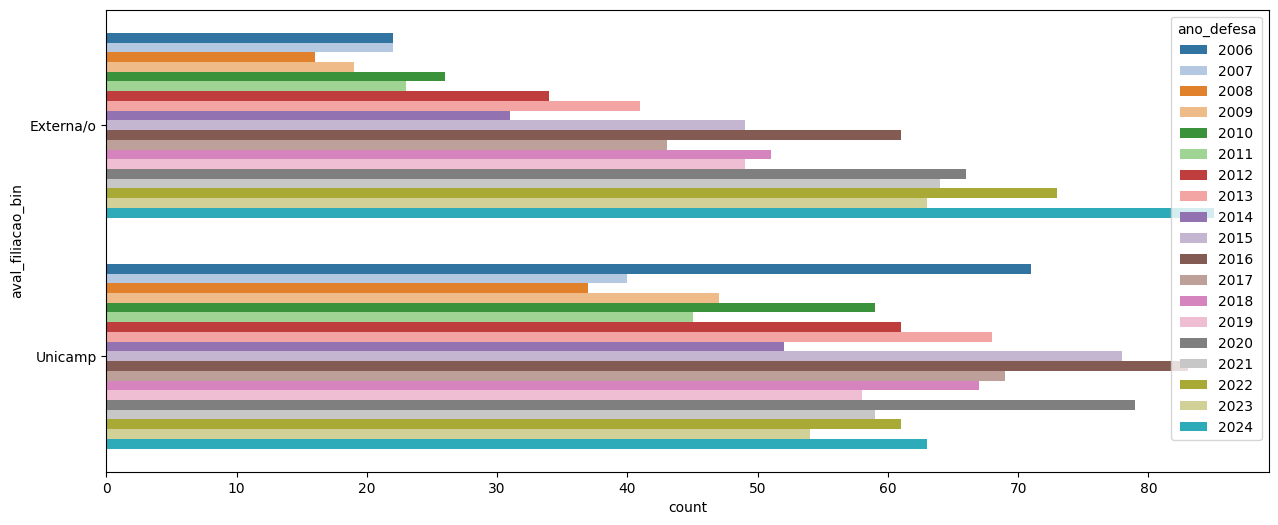

In [58]:
fig, ax = plt.subplots(ncols=1, figsize=(15,6), sharex=True)

sns.countplot(df, y="aval_filiacao_bin", hue="ano_defesa", ax=ax, order=("Externa/o", "Unicamp"), palette="tab20")

In [25]:
dict_ano = nx.get_edge_attributes(grafo_defesas, name="ano")

In [9]:
seed=1959

In [ ]:
pos = nx.arf_layout(grafo_defesas, a=2, seed=seed)

In [10]:
pos = nx.multipartite_layout(grafo_defesas, subset_key="filiacao_genero", scale=.10)

In [43]:
pos = nx.drawing.nx_pydot.graphviz_layout(grafo_defesas, prog="twopi")

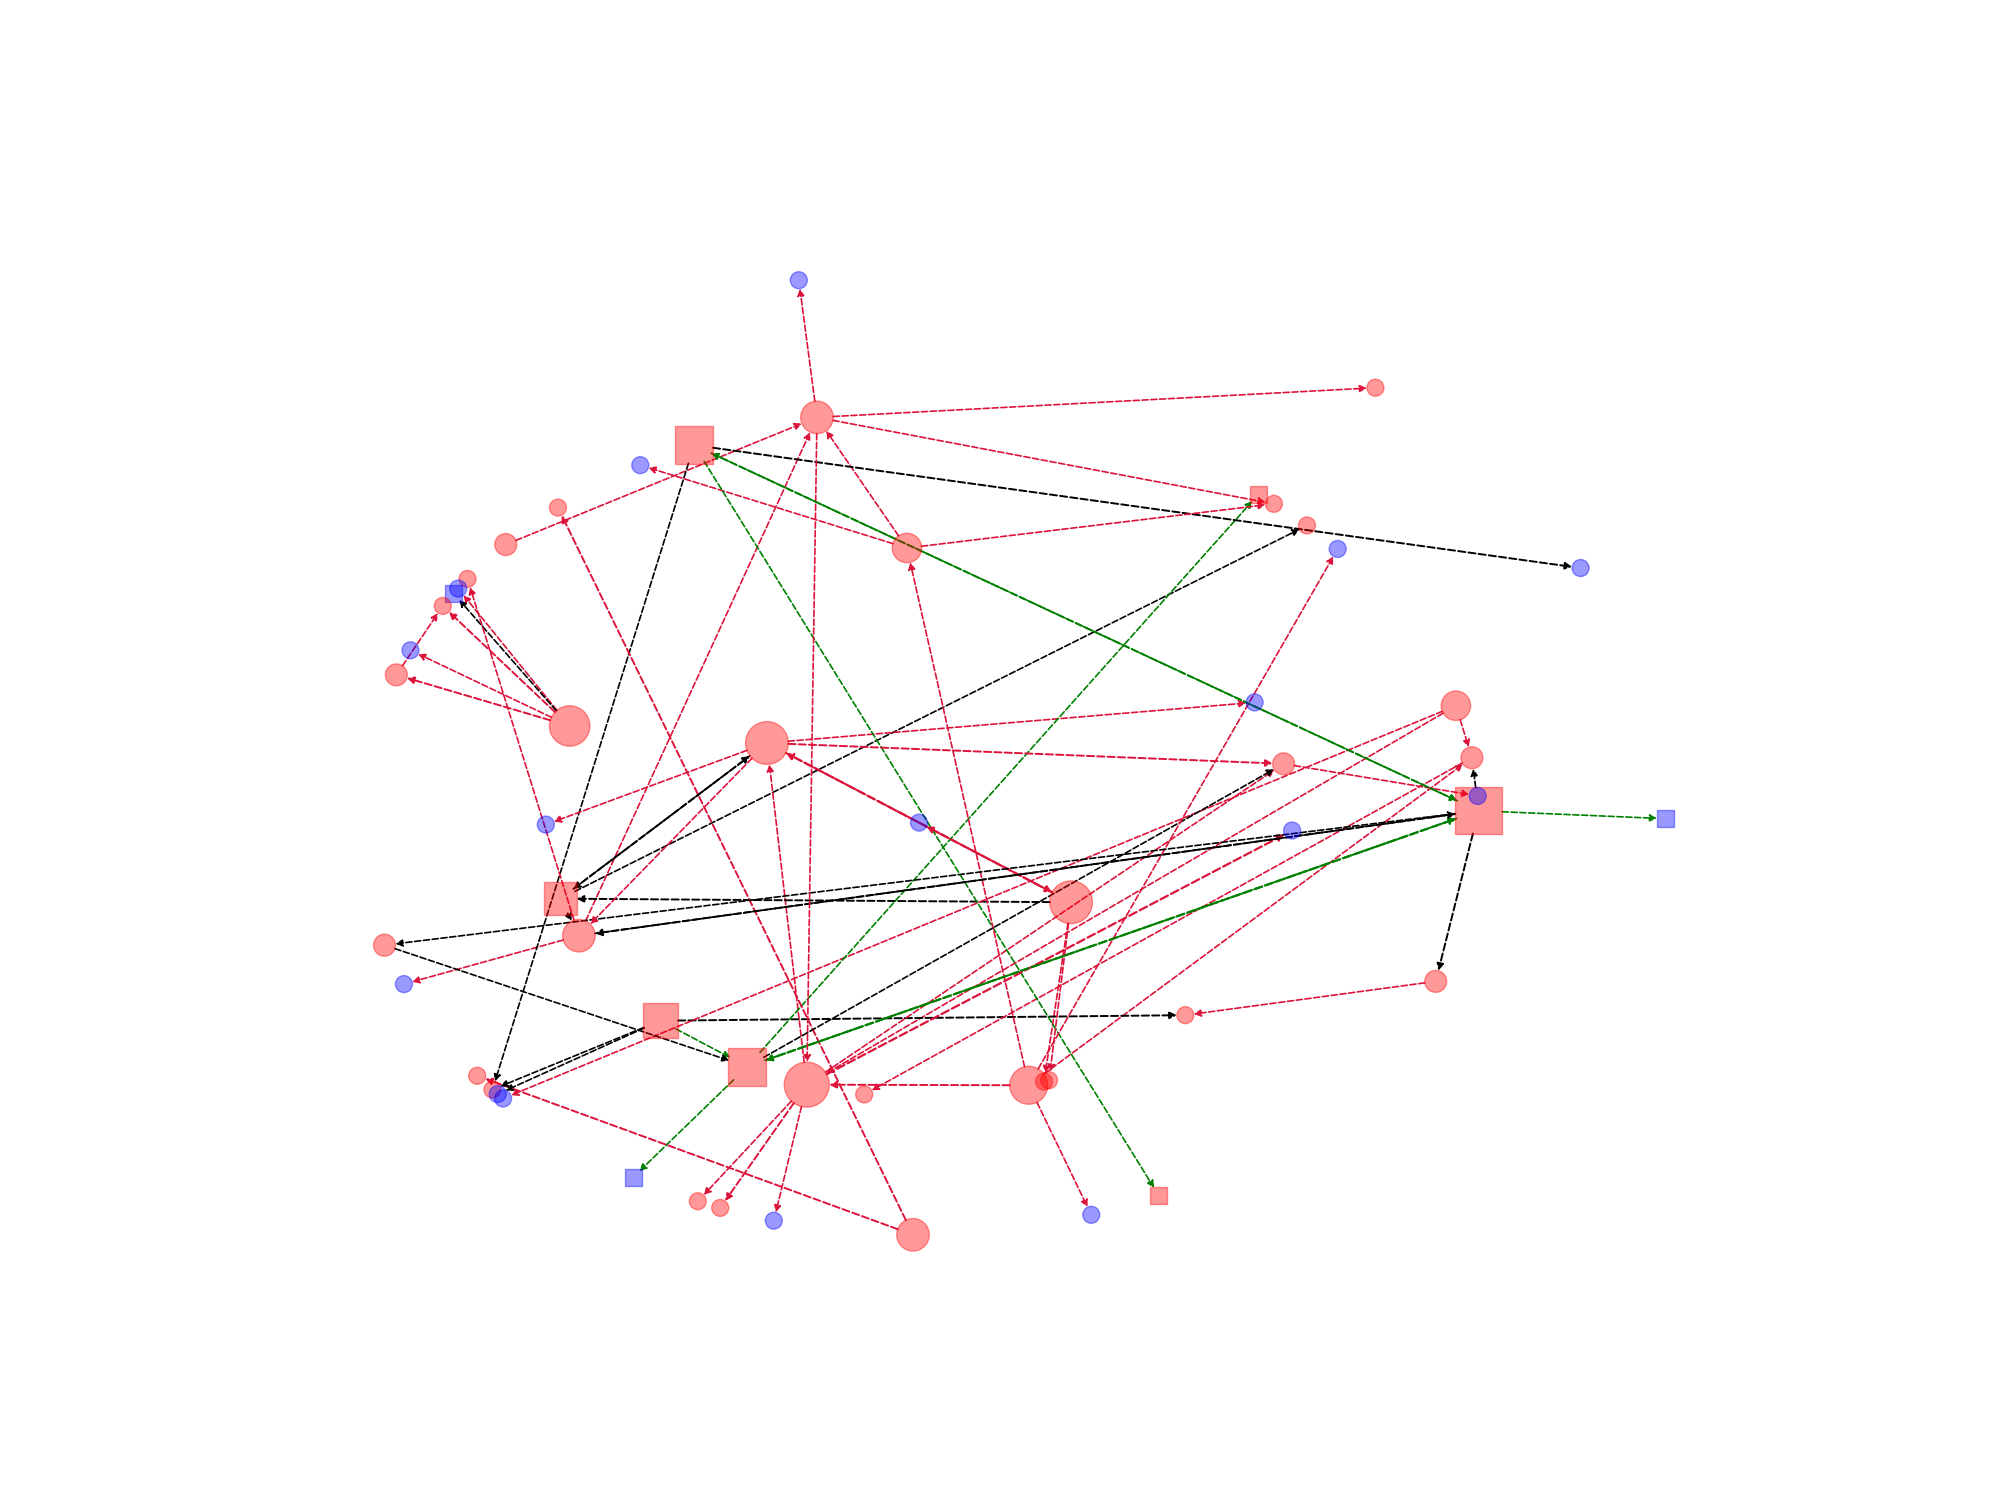

In [44]:
ano = 2006
edge_ano = []
nos_w_edge_ano = []
k_ano = []
pesos_arestas = collections.defaultdict(lambda:1.)
cores=collections.defaultdict(int)
marcadores=collections.defaultdict(str)
cores_bin=collections.defaultdict(int)
pesos = collections.defaultdict(lambda: 150)
cores_arestas = collections.defaultdict(lambda:"black")
for person1, person2, infos in grafo_defesas.edges(data=True):
    node1 = grafo_defesas.nodes[person1]
    node2 = grafo_defesas.nodes[person2]
    if infos["ano"] != ano: continue
    if node1["genero"] == node2["genero"]:
        if node1["genero"] == "Feminino":
            cores_arestas[(person1, person2)] = "green"
        else:
            cores_arestas[(person1, person2)] = "crimson"
    # else:
    #     cores_arestas.append("black")
    nos_w_edge_ano.append((person1, node1["genero"]))
    nos_w_edge_ano.append((person2, node2["genero"]))
    edge_ano.append((person1, person2))
    pesos_arestas[(person1, person2)]-=-.2
    pesos[person1]-=-100
    # pesos[person2]=150
    cores[person1]=node1["cor"]
    cores[person2]=node2["cor"]
    cores_bin[person1]=node1["cor_bin"]
    cores_bin[person2]=node2["cor_bin"]
    marcadores[person1]=node1["marker"]
    marcadores[person2]=node2["marker"]

node_color_F = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

node_color_M = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]

fig, ax = plt.subplots(ncols=1, figsize=(20,15))
col1 = nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
# nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                    #    node_color=node_color_F, node_size=np.array(node_size_F),node_shape="$F$")
col2 = nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
# nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                    #    node_color=node_color_M, node_size=np.array(node_size_M) // 2,node_shape="$M$")
_ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed",
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)],
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])

## show on hover
node_collections = [col1, col2]
nodes_list  = [[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
               [node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"]]

xy_all = []
node_all = []
col_index = []
for idx, (col, nlist) in enumerate(zip(node_collections, nodes_list)):
    xy = col.get_offsets()
    xy_all.append(xy)
    node_all.extend(nlist)
    col_index.extend([idx] * len(nlist))

xy_all = np.vstack(xy_all)


annot = ax.annotate(
    "", xy=(0, 0), xycoords="data", textcoords="offset points",
    xytext=(10, 10), ha="left",
    bbox=dict(boxstyle="round", fc="lightyellow", ec="gray")
)
annot.set_visible(False)

def update_annot(i):
    node = node_all[i]
    annot.xy = xy_all[i]
    data = grafo_defesas.nodes[node]
    annot.set_text(f"Node {node}\nNone: {data['nome']}\nIES: {data['filiacao']}")
    annot.set_visible(True)

def on_move(event):
    if event.inaxes != ax:
        return

    # Check all node_collections
    for col_idx_i, col in enumerate(node_collections):
        contains, ind = col.contains(event)
        if contains:
            # Map index inside this collection to global index
            local_i = ind["ind"][0]

            # Find actual global index
            global_i = np.where(np.array(col_index) == col_idx_i)[0][local_i]

            update_annot(global_i)
            fig.canvas.draw_idle()
            return

    # No hit → hide
    if annot.get_visible():
        annot.set_visible(False)
        fig.canvas.draw_idle()
fig.canvas.mpl_connect("motion_notify_event", on_move)
ax.set_axis_off()
plt.show()

In [ ]:
ano = 2006
for ano in range(2006, 2025):
    edge_ano = []
    nos_w_edge_ano = []
    k_ano = []
    pesos_arestas = collections.defaultdict(lambda:1.)
    cores=collections.defaultdict(int)
    marcadores=collections.defaultdict(str)
    cores_bin=collections.defaultdict(int)
    pesos = collections.defaultdict(lambda: 150)
    cores_arestas = collections.defaultdict(lambda:"black")
    for person1, person2, infos in grafo_defesas.edges(data=True):
        node1 = grafo_defesas.nodes[person1]
        node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        if node1["genero"] == node2["genero"]:
            if node1["genero"] == "Feminino":
                cores_arestas[(person1, person2)] = "green"
            else:
                cores_arestas[(person1, person2)] = "crimson"
        # else:
        #     cores_arestas.append("black")
        nos_w_edge_ano.append((person1, node1["genero"]))
        nos_w_edge_ano.append((person2, node2["genero"]))
        edge_ano.append((person1, person2))
        pesos_arestas[(person1, person2)]-=-.2
        pesos[person1]-=-100
        # pesos[person2]=150
        cores[person1]=node1["cor"]
        cores[person2]=node2["cor"]
        cores_bin[person1]=node1["cor_bin"]
        cores_bin[person2]=node2["cor_bin"]
        marcadores[person1]=node1["marker"]
        marcadores[person2]=node2["marker"]

    node_color_F = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

    node_color_M = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]

    fig, ax = plt.subplots(ncols=1, figsize=(20,15))
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        #    node_color=node_color_F, node_size=np.array(node_size_F),node_shape="$F$")
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        #    node_color=node_color_M, node_size=np.array(node_size_M) // 2,node_shape="$M$")
    _ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed",
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)],
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])
    # if ano == 2007: break
    break

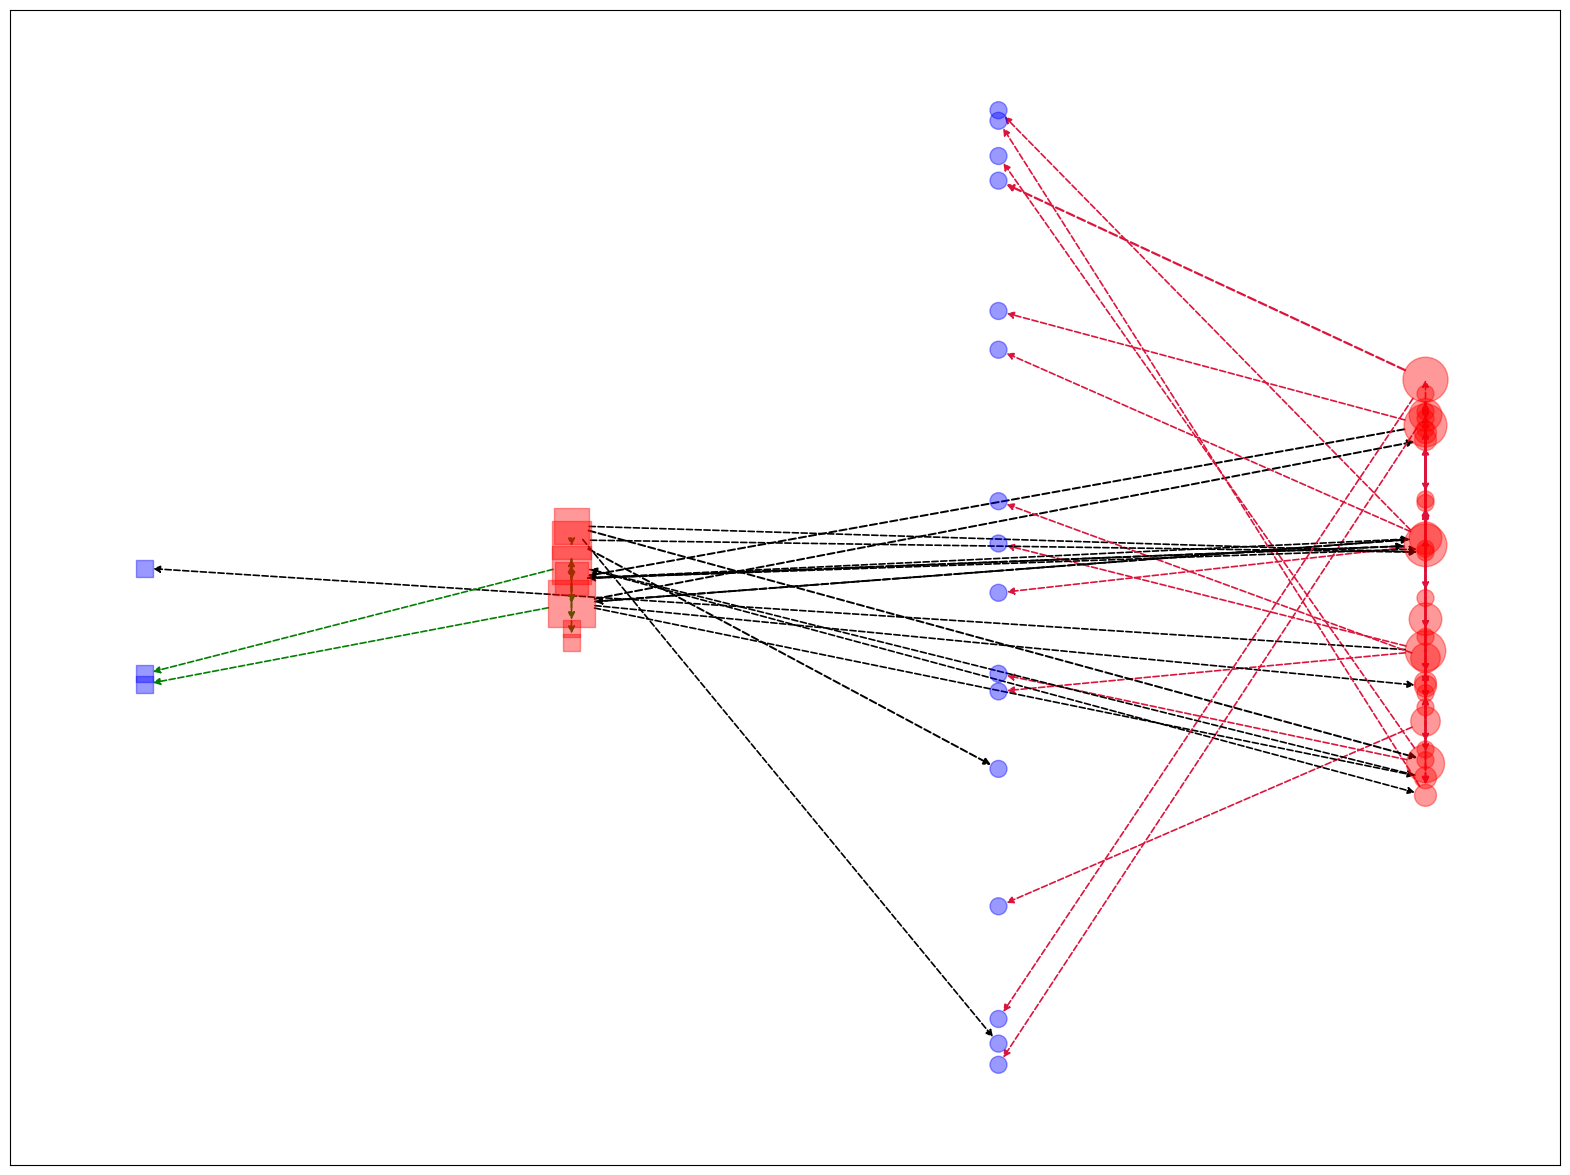

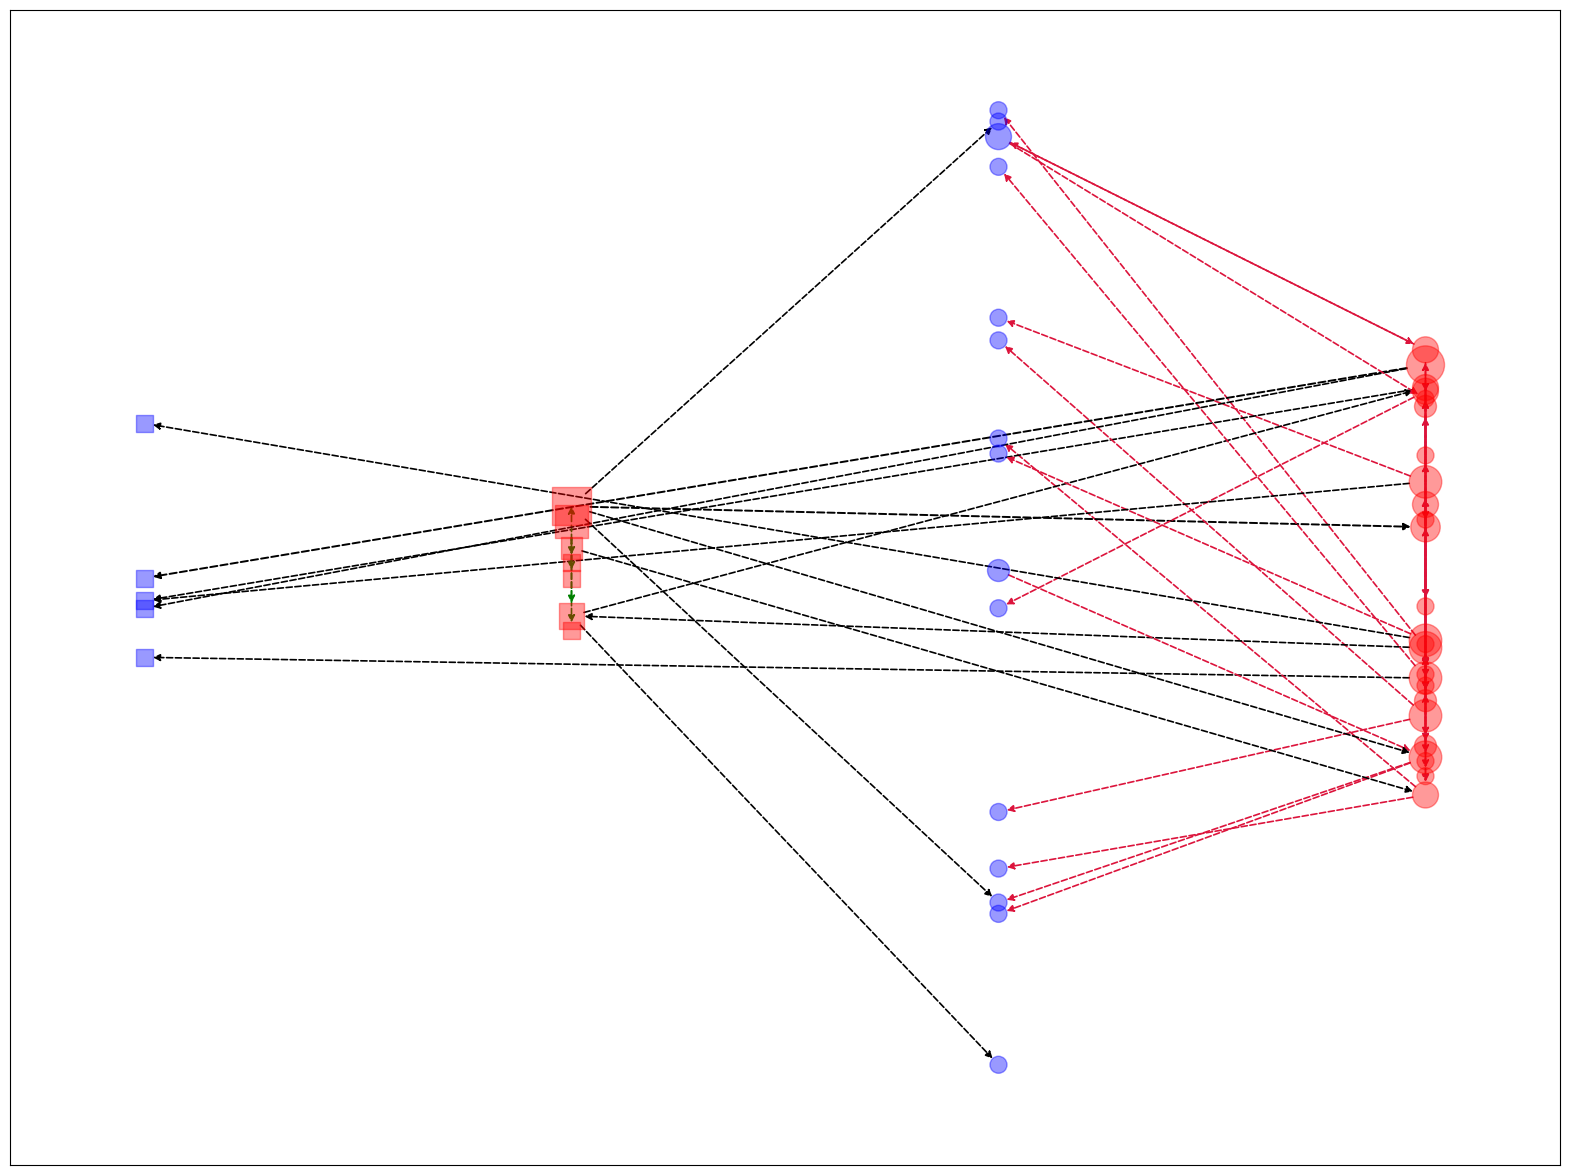

In [ ]:
ano = 2006
for ano in range(2006, 2025):
    edge_ano = []
    nos_w_edge_ano = []
    k_ano = []
    pesos_arestas = collections.defaultdict(lambda:1.)
    cores=collections.defaultdict(int)
    marcadores=collections.defaultdict(str)
    cores_bin=collections.defaultdict(int)
    pesos = collections.defaultdict(lambda: 150)
    cores_arestas = collections.defaultdict(lambda:"black")
    for person1, person2, infos in grafo_defesas.edges(data=True):
        node1 = grafo_defesas.nodes[person1]
        node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        if node1["genero"] == node2["genero"]:
            if node1["genero"] == "Feminino":
                cores_arestas[(person1, person2)] = "green"
            else:
                cores_arestas[(person1, person2)] = "crimson"
        # else:
        #     cores_arestas.append("black")
        nos_w_edge_ano.append((person1, node1["genero"]))
        nos_w_edge_ano.append((person2, node2["genero"]))
        edge_ano.append((person1, person2))
        pesos_arestas[(person1, person2)]-=-.2
        pesos[person1]-=-100
        # pesos[person2]=150
        cores[person1]=node1["cor"]
        cores[person2]=node2["cor"]
        cores_bin[person1]=node1["cor_bin"]
        cores_bin[person2]=node2["cor_bin"]
        marcadores[person1]=node1["marker"]
        marcadores[person2]=node2["marker"]

    node_color_F = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

    node_color_M = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]

    fig, ax = plt.subplots(ncols=1, figsize=(20,15))
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        #    node_color=node_color_F, node_size=np.array(node_size_F),node_shape="$F$")
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        #    node_color=node_color_M, node_size=np.array(node_size_M) // 2,node_shape="$M$")
    _ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed",
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)],
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])
    # if ano == 2007: break
    break

In [43]:
xlim_max, ylim_max = np.array([[p1, p2] for p1, p2 in pos.values()]).max(axis=0)
xlim_min, ylim_min = np.array([[p1, p2] for p1, p2 in pos.values()]).min(axis=0)

In [46]:
ano = 2006
edge_ano = []
nos_w_edge_ano = []
k_ano = []
pesos_arestas = collections.defaultdict(lambda:1.)
cores=collections.defaultdict(int)
marcadores=collections.defaultdict(str)
cores_bin=collections.defaultdict(int)
pesos = collections.defaultdict(lambda: 150)
cores_arestas = collections.defaultdict(lambda:"black")
scale=1
for ano in range(2006, 2025):

    for person1, person2, infos in grafo_defesas.edges(data=True):
        node1 = grafo_defesas.nodes[person1]
        node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        if node1["genero"] == node2["genero"]:
            if node1["genero"] == "Feminino":
                cores_arestas[(person1, person2)] = "green"
            else:
                cores_arestas[(person1, person2)] = "crimson"
        # else:
        #     cores_arestas.append("black")
        nos_w_edge_ano.append((person1, node1["genero"]))
        nos_w_edge_ano.append((person2, node2["genero"]))
        edge_ano.append((person1, person2))
        pesos_arestas[(person1, person2)]-=-.2
        pesos[person1]-=-100
        # pesos[person2]=150
        cores[person1]=node1["cor"]
        cores[person2]=node2["cor"]
        cores_bin[person1]=node1["cor_bin"]
        cores_bin[person2]=node2["cor_bin"]
        marcadores[person1]=node1["marker"]
        marcadores[person2]=node2["marker"]

    node_color_F = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
    node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

    node_color_M = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
    node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]

    fig, ax = plt.subplots(ncols=1, figsize=(20,20))
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        #    node_color=node_color_F, node_size=np.array(node_size_F),node_shape="$F$")
    nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
    # nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                        #    node_color=node_color_M, node_size=np.array(node_size_M) // 2,node_shape="$M$")
    _ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed",
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)],
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])
    # ax.set_ylim(ylim_min*(1/scale), ylim_max*scale)
    # ax.set_xlim(xlim_min*(1/scale), xlim_max*scale)
    ax.set_title(f"Ano: {ano}", fontsize=20)
    fig.savefig(f"images/evolucao_{ano}_pydot.png")
    plt.close(fig)
    # if ano == 2010: break

In [64]:
pos = nx.drawing.nx_pydot.graphviz_layout(grafo_defesas, prog="fdp")

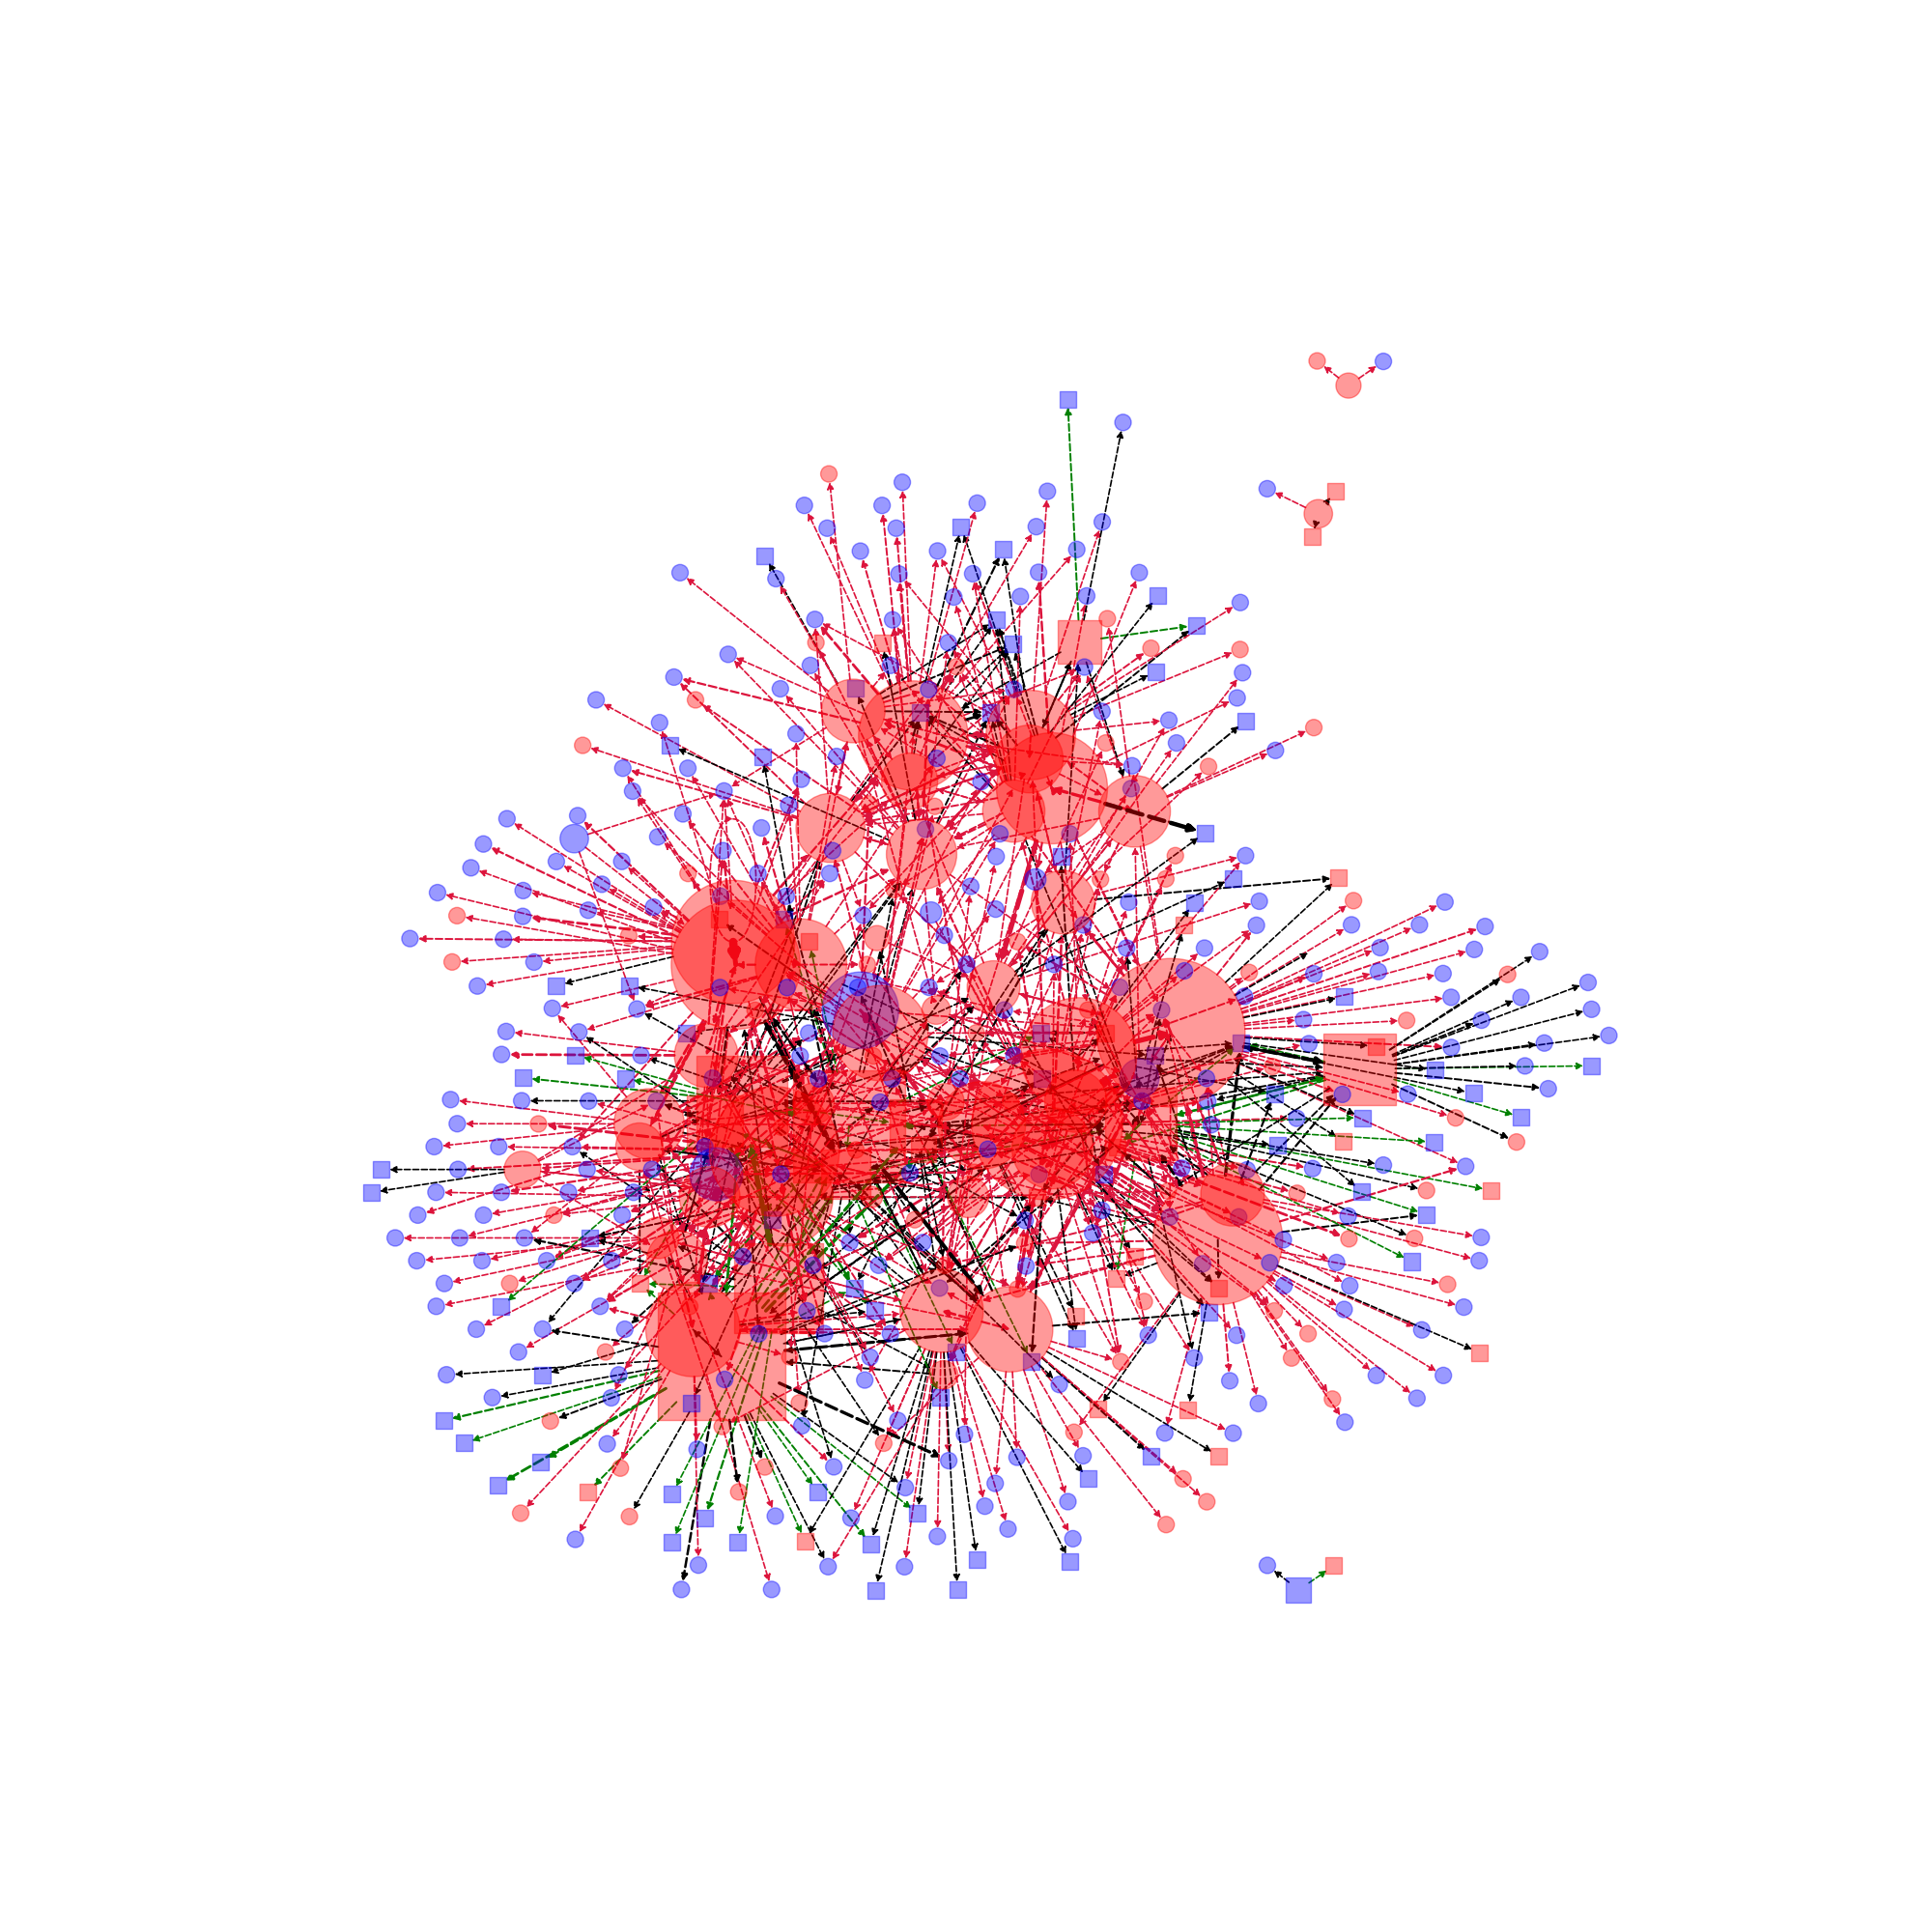

In [66]:
ano = 2006
edge_ano = []
nos_w_edge_ano = []
k_ano = []
pesos_arestas = collections.defaultdict(lambda:1.)
cores=collections.defaultdict(int)
marcadores=collections.defaultdict(str)
cores_bin=collections.defaultdict(int)
pesos = collections.defaultdict(lambda: 150)
cores_arestas = collections.defaultdict(lambda:"black")
scale=1.25
for ano in range(2006, 2025):

    for person1, person2, infos in grafo_defesas.edges(data=True):
        node1 = grafo_defesas.nodes[person1]
        node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        if node1["genero"] == node2["genero"]:
            if node1["genero"] == "Feminino":
                cores_arestas[(person1, person2)] = "green"
            else:
                cores_arestas[(person1, person2)] = "crimson"
        # else:
        #     cores_arestas.append("black")
        nos_w_edge_ano.append((person1, node1["genero"]))
        nos_w_edge_ano.append((person2, node2["genero"]))
        edge_ano.append((person1, person2))
        pesos_arestas[(person1, person2)]-=-.2
        pesos[person1]-=-100
        # pesos[person2]=150
        cores[person1]=node1["cor"]
        cores[person2]=node2["cor"]
        cores_bin[person1]=node1["cor_bin"]
        cores_bin[person2]=node2["cor_bin"]
        marcadores[person1]=node1["marker"]
        marcadores[person2]=node2["marker"]

node_color_F = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

node_color_M = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]

node_sizes = node_size_F+node_size_M
node_shapes = node_shape_F+node_shape_M

fig, ax = plt.subplots(ncols=1, figsize=(20,20))
col1 = nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
# nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                    #    node_color=node_color_F, node_size=np.array(node_size_F),node_shape="$F$")
col2 = nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
# nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                    #    node_color=node_color_M, node_size=np.array(node_size_M) // 2,node_shape="$M$")
_ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed",
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)],
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])

## show on hover
node_collections = [col1, col2]
nodes_list  = [[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
               [node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"]]

xy_all = []
node_all = []
col_index = []
for idx, (col, nlist) in enumerate(zip(node_collections, nodes_list)):
    xy = col.get_offsets()
    xy_all.append(xy)
    node_all.extend(nlist)
    col_index.extend([idx] * len(nlist))

xy_all = np.vstack(xy_all)


annot = ax.annotate(
    "", xy=(0, 0), xycoords="data", textcoords="offset points",
    xytext=(10, 10), ha="left",
    bbox=dict(boxstyle="round", fc="lightyellow", ec="gray")
)
annot.set_visible(False)
highlight = ax.scatter([], [], s=600, facecolor="none", edgecolors="cyan", linewidth=2, zorder=5)
highlight.set_visible(False)

def update_annot(i):
    node = node_all[i]
    annot.xy = xy_all[i]
    data = grafo_defesas.nodes[node]
    highlight.set_offsets([xy_all[i]])
    highlight.set_sizes([node_sizes[i]])
    # highlight.set_marker(node_shapes[i])
    highlight.set_visible(True)
    annot.set_text(f"Node {node}\nNone: {data['nome']}\nIES: {data['filiacao']}")
    annot.set_visible(True)

def on_move(event):
    if event.inaxes != ax:
        return

    # Check all node_collections
    for col_idx_i, col in enumerate(node_collections):
        contains, ind = col.contains(event)
        if contains:
            # Map index inside this collection to global index
            local_i = ind["ind"][0]

            # Find actual global index
            global_i = np.where(np.array(col_index) == col_idx_i)[0][local_i]

            update_annot(global_i)
            fig.canvas.draw_idle()
            return

    # No hit → hide
    if annot.get_visible():
        annot.set_visible(False)
        highlight.set_visible(False)
        fig.canvas.draw_idle()
fig.canvas.mpl_connect("motion_notify_event", on_move)
ax.set_axis_off()
plt.show()

In [9]:
pos = nx.drawing.nx_pydot.graphviz_layout(grafo_defesas, prog="twopi")

In [20]:
pesos[u]

350

In [33]:
tam_u

350

In [32]:
np.array(pos[u])

array([511.71, 896.  ])

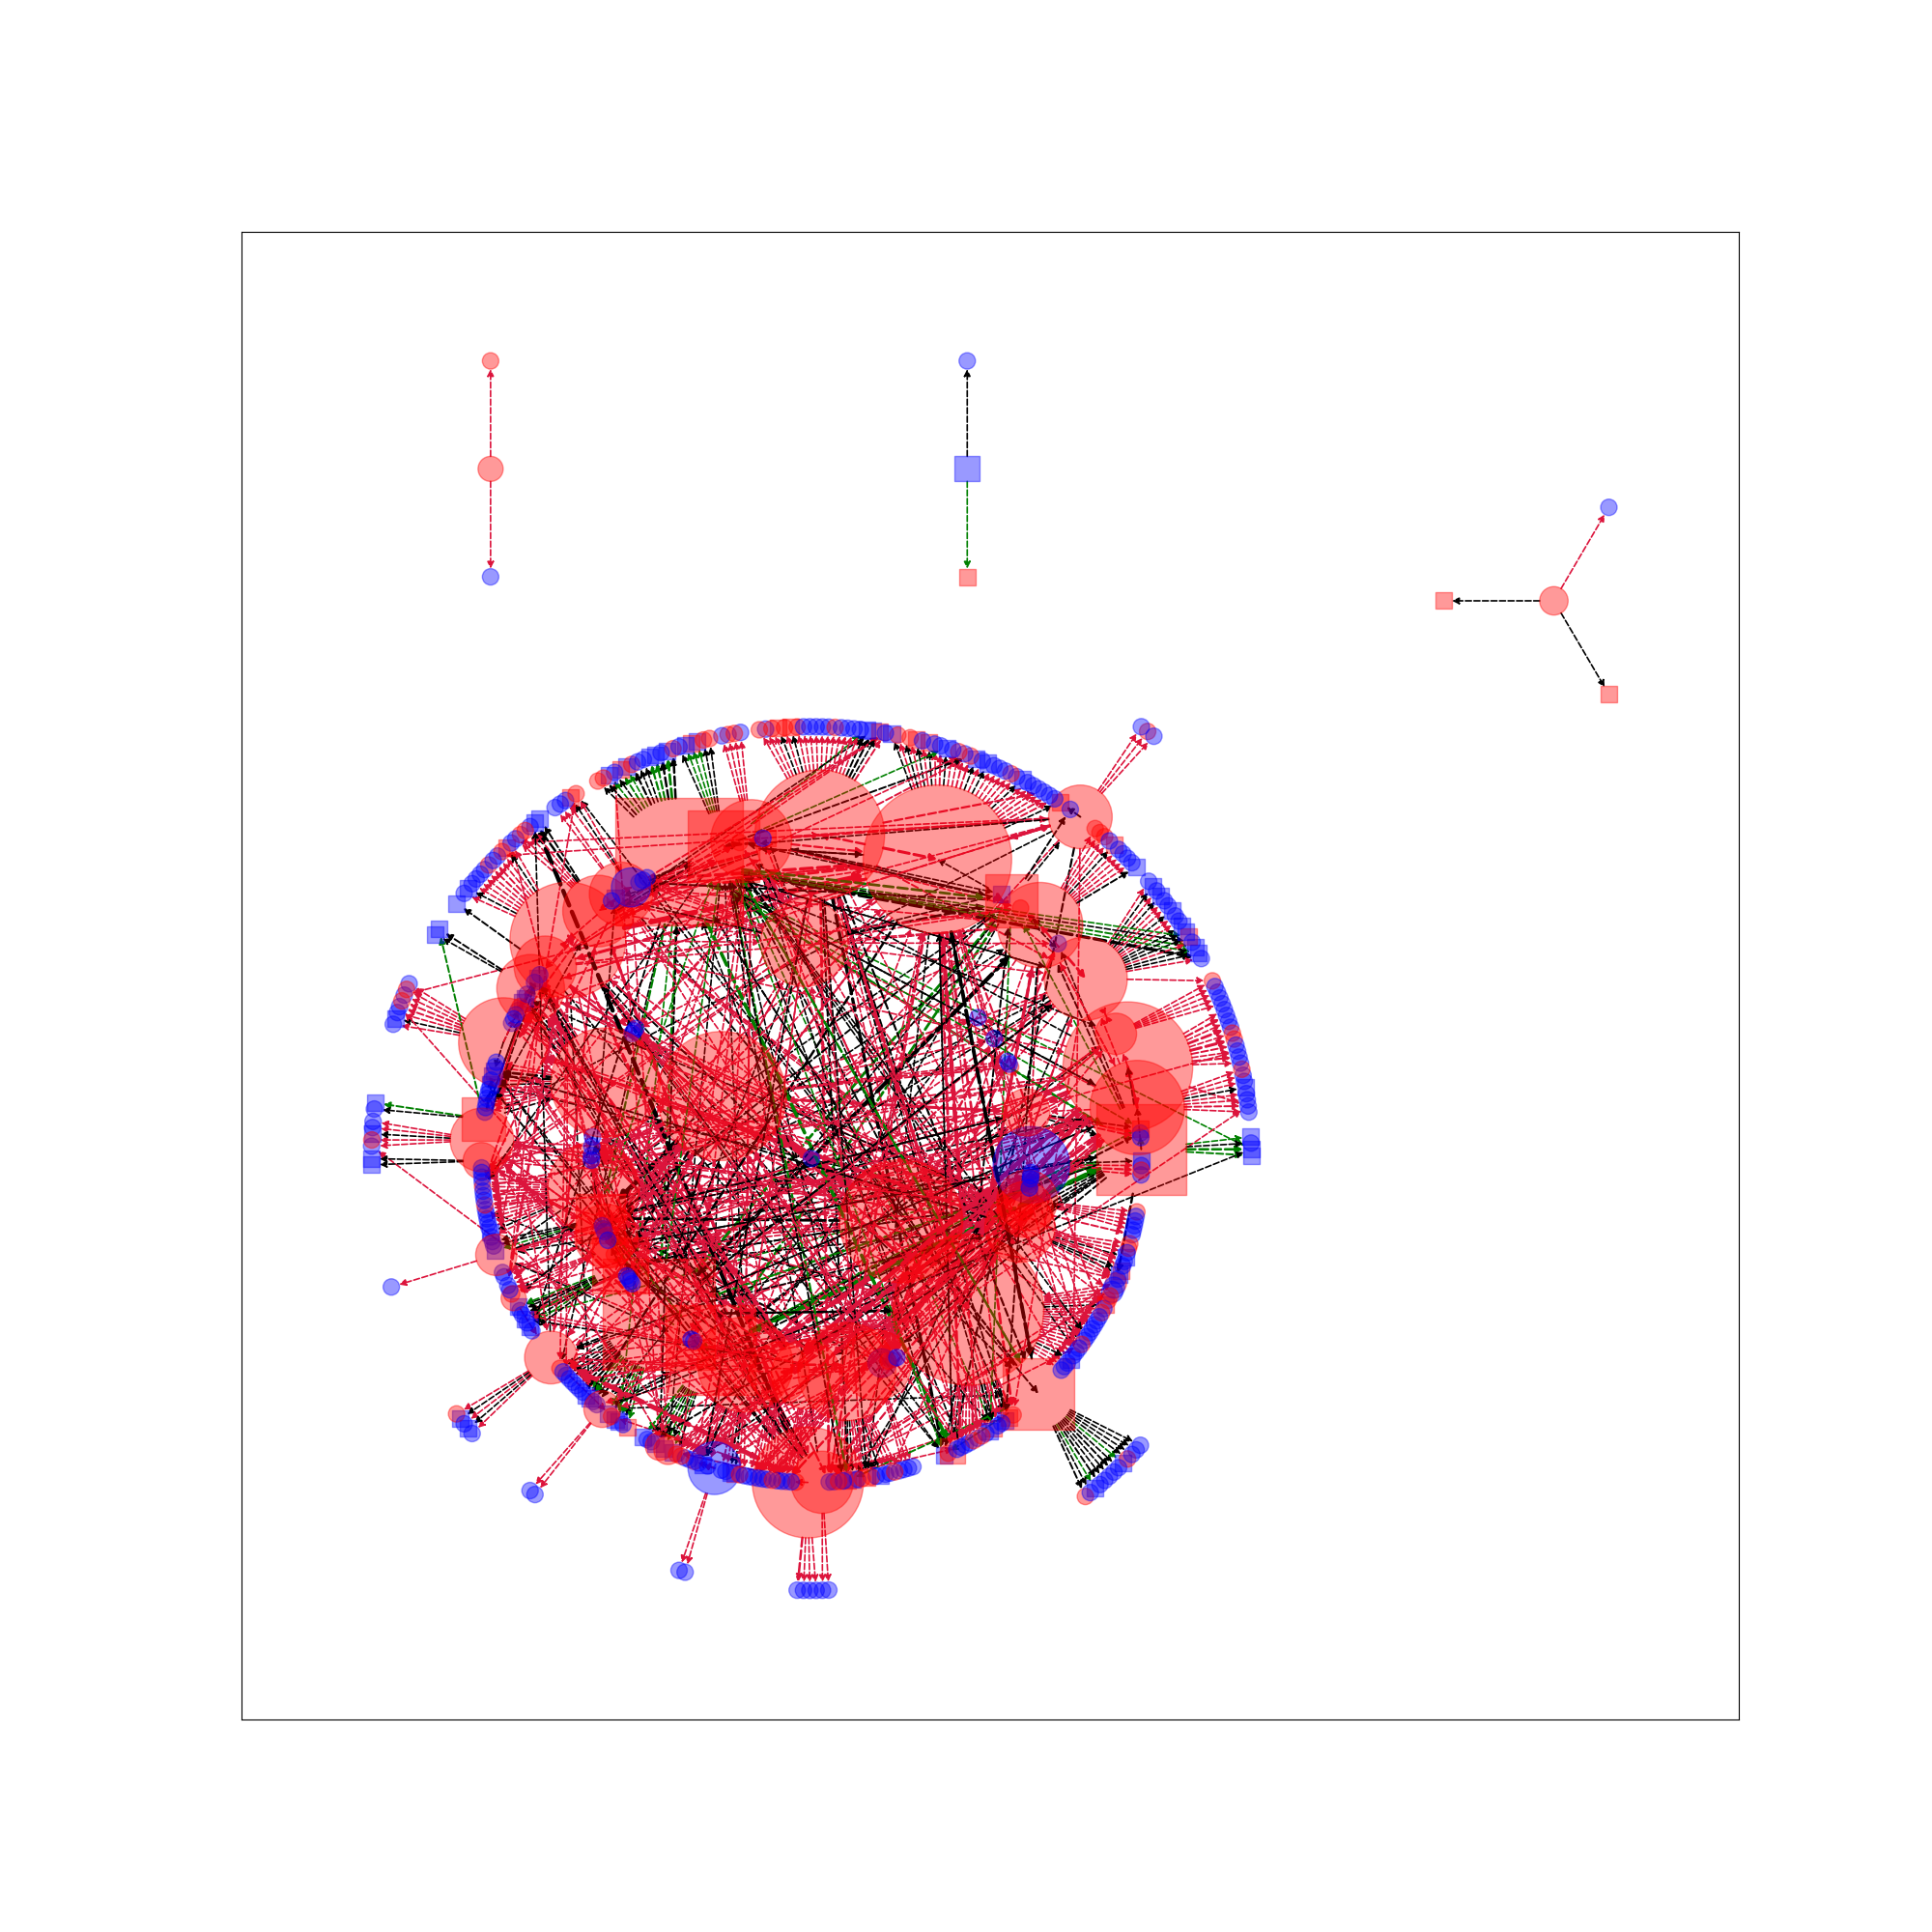

In [37]:
ano = 2006
edge_ano = []
nos_w_edge_ano = []
k_ano = []
pesos_arestas = collections.defaultdict(lambda:1.)
cores=collections.defaultdict(int)
marcadores=collections.defaultdict(str)
cores_bin=collections.defaultdict(int)
pesos = collections.defaultdict(lambda: 150)
cores_arestas = collections.defaultdict(lambda:"black")
scale=1.25
for ano in range(2006, 2025):

    for person1, person2, infos in grafo_defesas.edges(data=True):
        node1 = grafo_defesas.nodes[person1]
        node2 = grafo_defesas.nodes[person2]
        if infos["ano"] != ano: continue
        if node1["genero"] == node2["genero"]:
            if node1["genero"] == "Feminino":
                cores_arestas[(person1, person2)] = "green"
            else:
                cores_arestas[(person1, person2)] = "crimson"
        # else:
        #     cores_arestas.append("black")
        nos_w_edge_ano.append((person1, node1["genero"]))
        nos_w_edge_ano.append((person2, node2["genero"]))
        edge_ano.append((person1, person2))
        pesos_arestas[(person1, person2)]-=-.2
        pesos[person1]-=-100
        # pesos[person2]=150
        cores[person1]=node1["cor"]
        cores[person2]=node2["cor"]
        cores_bin[person1]=node1["cor_bin"]
        cores_bin[person2]=node2["cor_bin"]
        marcadores[person1]=node1["marker"]
        marcadores[person2]=node2["marker"]

node_color_F = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
node_size_F = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]
node_shape_F = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Feminino"]

node_color_M = [cores_bin[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
node_size_M = [pesos[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]
node_shape_M = [marcadores[node] for node, gender in set(nos_w_edge_ano) if gender == "Masculino"]

node_sizes = node_size_F+node_size_M
node_shapes = node_shape_F+node_shape_M

fig, ax = plt.subplots(ncols=1, figsize=(20,20))
col1 = nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                        node_color=node_color_F, node_size=node_size_F,node_shape="s", alpha=.4)
# nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
                    #    node_color=node_color_F, node_size=np.array(node_size_F),node_shape="$F$")
col2 = nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                                        node_color=node_color_M, node_size=node_size_M,node_shape="o", alpha=.4)
# nx.draw_networkx_nodes(grafo_defesas, pos=pos, nodelist=[node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"],
                    #    node_color=node_color_M, node_size=np.array(node_size_M) // 2,node_shape="$M$")
_ = nx.draw_networkx_edges(grafo_defesas, pos=pos, edgelist=list(set(edge_ano)), style="dashed",
                            width=[pesos_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            edge_color=[cores_arestas[(person1, person2)] for person1, person2 in set(edge_ano)],
                            nodelist=[node for node, _ in set(nos_w_edge_ano)],
                            node_size=[pesos[node] for node, _ in set(nos_w_edge_ano)])

## show on hover
node_collections = [col1, col2]
nodes_list  = [[node for node, gender in set(nos_w_edge_ano) if gender=="Feminino"],
               [node for node, gender in set(nos_w_edge_ano) if gender=="Masculino"]]

xy_all = []
node_all = []
col_index = []
for idx, (col, nlist) in enumerate(zip(node_collections, nodes_list)):
    xy = col.get_offsets()
    xy_all.append(xy)
    node_all.extend(nlist)
    col_index.extend([idx] * len(nlist))
xy_all = np.vstack(xy_all)

edge_coords = []
edges = list(grafo_defesas.edges())
for u, v in edges:
    tam_u, tam_v = pesos[u], pesos[v]
    edge_coords.append([np.array(pos[u]), np.array(pos[v])])
edge_collection = LineCollection(
    edge_coords,
    colors="gray",
    linewidths=1.0,
    alpha=0,
    zorder=1,
    picker=True   # <-- necessary for clickable edges
)
ax.add_collection(edge_collection)

# --- Edge highlight collection (empty at start) ---
edge_highlight = LineCollection(
    [],
    colors="cyan",
    linewidths=3.0,
    zorder=5
)
ax.add_collection(edge_highlight)
edge_highlight.set_visible(False)

annot = ax.annotate(
    "", xy=(0, 0), xycoords="data", textcoords="offset points",
    xytext=(10, 10), ha="left",
    bbox=dict(boxstyle="round", fc="lightyellow", ec="gray")
)
annot.set_visible(False)
highlight = ax.scatter([], [], s=600, facecolor="none", edgecolors="cyan", linewidth=2, zorder=5)
highlight.set_visible(False)

def update_annot(i):
    node = node_all[i]
    annot.xy = xy_all[i]
    data = grafo_defesas.nodes[node]
    highlight.set_offsets([xy_all[i]])
    highlight.set_sizes([node_sizes[i]])
    # highlight.set_marker(node_shapes[i])
    highlight.set_visible(True)
    annot.set_text(f"Node {node}\nNone: {data['nome']}\nIES: {data['filiacao']}")
    annot.set_visible(True)

# def on_move(event):
#     if event.inaxes != ax:
#         return

#     # Check all node_collections
#     for col_idx_i, col in enumerate(node_collections):
#         contains, ind = col.contains(event)
#         if contains:
#             # Map index inside this collection to global index
#             local_i = ind["ind"][0]

#             # Find actual global index
#             global_i = np.where(np.array(col_index) == col_idx_i)[0][local_i]

#             update_annot(global_i)
#             fig.canvas.draw_idle()
#             return

#     # No hit → hide
#     if annot.get_visible():
#         annot.set_visible(False)
#         highlight.set_visible(False)
#         fig.canvas.draw_idle()
def on_click(event):
    # not inside the axis → clear
    if event.inaxes != ax:
        annot.set_visible(False)
        highlight.set_visible(False)
        edge_highlight.set_visible(False)
        fig.canvas.draw_idle()
        return
    # check node collections for hits
    for col_idx_i, col in enumerate(node_collections):
        contains, ind = col.contains(event)
        if contains:
            local_i = ind["ind"][0]

            # Map (collection, local_index) → global index
            global_i = np.where(np.array(col_index) == col_idx_i)[0][local_i]

            update_annot(global_i)
            fig.canvas.draw_idle()
            return
    contains, edge_info = edge_collection.contains(event)
    if contains:
        seg_index = edge_info["ind"][0]

        # set the selected edge as highlighted
        edge_highlight.set_segments([edge_coords[seg_index]])
        edge_highlight.set_visible(True)

        # annot.set_visible(False)
        # highlight.set_visible(False)
        fig.canvas.draw_idle()
        return
    annot.set_visible(False)
    highlight.set_visible(False)
    edge_highlight.set_visible(False)
    fig.canvas.draw_idle()
    
# fig.canvas.mpl_connect("motion_notify_event", on_move)
fig.canvas.mpl_connect("button_press_event", on_click)
# fig.canvas.layout.width = "1000px"
# fig.canvas.layout.height = "1000px"
# ax.set_axis_off()
plt.show()